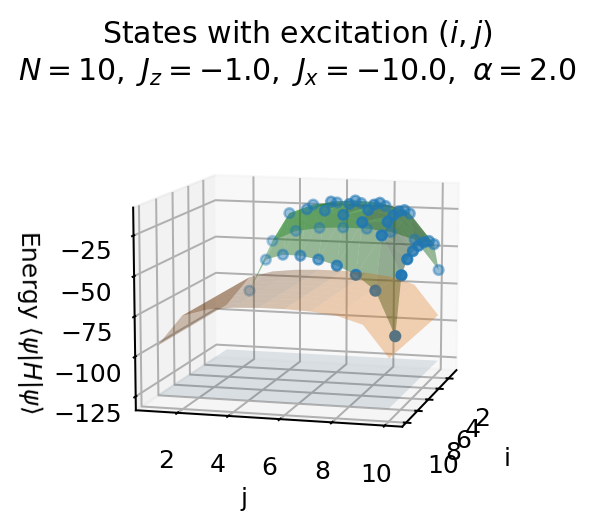

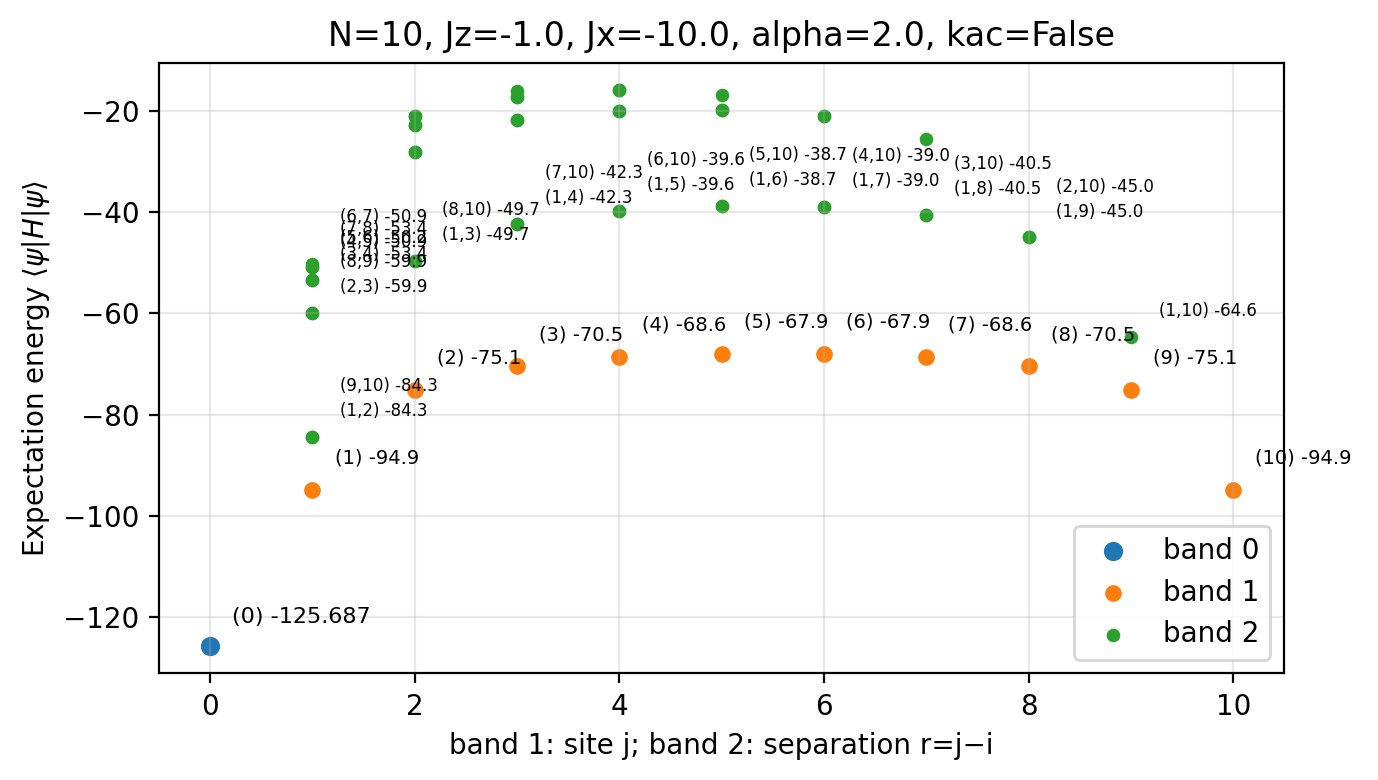

(Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], shape=(1024, 1024), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[ -9.   0.   0. ...   0.   0.   0.]
  [  0.  -7. -10. ...   0.   0.   0.]
  [  0. -10.  -5. ...   0.   0.   0.]
  ...
  [  0.   0.   0. ...  -5. -10.   0.]
  [  0.   0.   0. ... -10.  -7.   0.]
  [  0.   0.   0. ...   0.   0.  -9.]],
 -125.68709057697278,
 (array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
  array([-94.89173595, -75.13864953, -70.45114953, -68.63709058,
         -67.94264613, -67.94264613, -68.63709058, -70.45114953,
         -75.13864953, -94.89173595])),
 ([(1, 2),
   (1, 3),
   (1, 4),
   (1, 5),
   (1, 6),
   (1, 7),
   (1, 8),
   (1, 9),
   (1, 10),
   (2, 3),
   (2, 4),
   (2, 5),
   (2, 6),
   (2, 7),
   (2, 8),
   (2, 9),
   (2, 10),
   (3, 4),
   (3, 5),
   (3, 6),
   (3, 7),
   (3, 8),
   (3, 9),
   (3, 10),
   (4, 5),
   (4, 6),
   (4, 7),
   (4, 8),
   (4, 9),
   (4, 10),
   (5, 6),
   (5, 7),
   (5, 8

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
# -----------------------------
# Operator constructors
# -----------------------------

def op_on_site(op: qt.Qobj, N: int, site: int) -> qt.Qobj:
    if N <= 0:
        raise ValueError("N must be positive.")
    if not (0 <= site < N):
        raise ValueError(f"site={site} out of range for N={N}.")
    ops = [qt.qeye(2)] * N
    ops[site] = op
    return qt.tensor(ops)


def two_site_op(opA: qt.Qobj, opB: qt.Qobj, N: int, i: int, j: int) -> qt.Qobj:
    if N <= 0:
        raise ValueError("N must be positive.")
    if i == j:
        raise ValueError("i and j must be different sites.")
    if not (0 <= i < N and 0 <= j < N):
        raise ValueError(f"Sites (i={i}, j={j}) out of range for N={N}.")
    ops = [qt.qeye(2)] * N
    ops[i] = opA
    ops[j] = opB
    return qt.tensor(ops)


# -----------------------------
# Hamiltonian
# -----------------------------

def kac_factor(N: int, alpha: float) -> float:
    """
    Returns Kac factor K such that Jx_eff = Jx / K.
    Matches: K = sum_{i<j} 1/r^alpha divided by (N-1).
    """
    r = np.arange(1, N, dtype=float)
    # sum_{i<j} 1/r^alpha = sum_{r=1}^{N-1} (N-r)/r^alpha
    sumV = np.sum((N - r) / (r ** alpha))
    return sumV / (N - 1)


def build_H(N: int, Jz: float, Jx: float, alpha: float, kac: bool = True) -> qt.Qobj:
    if N < 2:
        raise ValueError("N must be >= 2.")
    if alpha < 0:
        raise ValueError("alpha must be >= 0.")

    sx, sz = qt.sigmax(), qt.sigmaz()
    H = 0

    if kac:
        K = kac_factor(N, alpha)
        Jx = Jx / K  # rescaled long-range prefactor

    # Nearest-neighbor zz
    for j in range(N - 1):
        H += Jz * two_site_op(sz, sz, N, j, j + 1)

    # xx term
    if alpha >= 100:
        for j in range(N - 1):
            H += Jx * two_site_op(sx, sx, N, j, j + 1)
    else:
        for i in range(N):
            for j in range(i + 1, N):
                r = j - i
                H += (Jx / (r ** alpha)) * two_site_op(sx, sx, N, i, j)

    return H

def plus_minus_x():
    plus_x  = (qt.basis(2, 0) + qt.basis(2, 1)).unit()
    minus_x = (qt.basis(2, 0) - qt.basis(2, 1)).unit()
    return plus_x, minus_x

def band0_ket_x(N: int) -> qt.Qobj:
    plus_x, minus_x = plus_minus_x()
    return qt.tensor([minus_x]*N).unit()

def band1_ket_x(N: int, site: int) -> qt.Qobj:
    plus_x, minus_x = plus_minus_x()
    kets = [minus_x for _ in range(N)]
    kets[site] = plus_x
    return qt.tensor(kets).unit()

def band2_ket_x(N: int, i: int, j: int) -> qt.Qobj:
    if i == j:
        raise ValueError("i and j must be different.")
    plus_x, minus_x = plus_minus_x()
    kets = [minus_x for _ in range(N)]
    kets[i] = plus_x
    kets[j] = plus_x
    return qt.tensor(kets).unit()


def band_expectation_energies(N, Jz, Jx, alpha, kac=True):
    H = build_H(N, Jz, Jx, alpha, kac=kac)

    # --- band 0 ---
    psi0 = band0_ket_x(N)
    E0 = float(qt.expect(H, psi0).real)

    # --- band 1 ---
    j_sites = np.arange(1, N+1, dtype=int)        # 1..N for plotting labels
    E1 = np.zeros(N, dtype=float)
    for j in range(N):
        E1[j] = float(qt.expect(H, band1_ket_x(N, j)).real)

    # --- band 2 (NC2) ---
    pairs = []
    E2 = []
    for i in range(N):
        for j in range(i+1, N):
            pairs.append((i+1, j+1))  # store 1-indexed labels
            E2.append(float(qt.expect(H, band2_ket_x(N, i, j)).real))
    E2 = np.array(E2, dtype=float)

    return H, E0, (j_sites, E1), (pairs, E2)



def plot_bands(N, Jz, Jx, alpha, kac=True):
    H, E0, (j_sites, E1), (pairs, E2) = band_expectation_energies(N, Jz, Jx, alpha, kac=kac)

    # separation r = j - i (pairs are 1-indexed in my earlier code)
    r_vals = np.array([j - i for (i, j) in pairs], dtype=int)

    # Bigger, higher-res figure so labels are legible
    plt.figure(figsize=(7, 4), dpi=200)

    # ---- band 0 ----
    plt.scatter([0], [E0], s=35, marker='o', label="band 0")
    plt.annotate(f"(0) {E0:.3f}", xy=(0, E0), xytext=(8, 8),
                 textcoords="offset points", fontsize=8)

    # ---- band 1 ----
    plt.scatter(j_sites, E1, s=25, marker='o', label="band 1")

    # Label band-1 points: offset upward; stack if needed (usually not needed)
    from collections import defaultdict
    offset_b1 = defaultdict(int)

    for x, y in zip(j_sites, E1):
        k = offset_b1[x]
        offset_b1[x] += 1
        dx = 8
        dy = 8 + 10 * k  # grows, no modulo collisions

        plt.annotate(
            f"({x}) {y:.1f} ", #{y:.3f}
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=7
        )

    # ---- band 2 ----
    # If you want *true* coordinates for reading r and E:
    # keep points at (r_vals, E2) and only offset the labels.
    plt.scatter(r_vals, E2, s=15, marker='o', label="band 2")

    # Collision handling for band-2 labels:
    # bucket by (r, rounded E) so exactly/near-degenerate points get stacked
    key_counts = defaultdict(int)

    for r, E, (i, j) in zip(r_vals, E2, pairs):
        key = (int(r), float(np.round(E, 10)))  # rounding controls "degeneracy" grouping
        k = key_counts[key]
        key_counts[key] += 1

        # screen-space offsets (points): shift to the right, and stack upward
        dx = 10
        dy = 6 + 9 * k

        if(E<-30):
            plt.annotate(
                f"({i},{j}) {E:.1f}", #  {E:.3f}
                xy=(r, E),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=6
            )

    plt.xlabel("band 1: site j; band 2: separation r=j−i")
    plt.ylabel(r"Expectation energy $\langle \psi | H | \psi \rangle$")
    plt.title(f"N={N}, Jz={Jz}, Jx={Jx}, alpha={alpha}, kac={kac}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("plt/plotbands2d.pdf")
    plt.show()

    return H, E0, (j_sites, E1), (pairs, E2)


import numpy as np
import matplotlib.pyplot as plt

def plot_bands_3d(N, Jz, Jx, alpha, kac=True,
                  sheet_halfwidth=2, annotate_band2=True):
    H, E0, (j_sites, E1), (pairs, E2) = band_expectation_energies(
        N, Jz, Jx, alpha, kac=kac
    )

    # --- band-2 arrays (pairs are 1-indexed) ---
    i_vals = np.array([i for (i, j) in pairs], dtype=int)
    j_vals = np.array([j for (i, j) in pairs], dtype=int)
    E2_vals = np.array(E2, dtype=float)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # -----------------------
    # Band 0: flat plane z=E0
    # -----------------------
    grid = np.arange(1, N + 1)
    I0, J0 = np.meshgrid(grid, grid, indexing="ij")
    Z0 = np.full_like(I0, float(E0), dtype=float)
    ax.plot_surface(I0, J0, Z0, alpha=0.15, linewidth=0, antialiased=True)

    # ----------------------------------------
    # Band 1: ribbon/sheet around i=j diagonal
    # z depends only on j: z = E1(j)
    # ----------------------------------------
    j_sites_arr = np.array(j_sites, dtype=int)     # expected 1..N
    E1_arr = np.array(E1, dtype=float)

    # map E1(j) into a convenient lookup array of length N+1 (1-indexed)
    E1_lookup = np.empty(N + 1, dtype=float)
    E1_lookup[:] = np.nan
    E1_lookup[j_sites_arr] = E1_arr

    deltas = np.arange(-sheet_halfwidth, sheet_halfwidth + 1, dtype=int)  # thickness
    J_sheet, D_sheet = np.meshgrid(j_sites_arr, deltas, indexing="xy")    # shape: (len(deltas), N)
    I_sheet = J_sheet + D_sheet
    Z_sheet = E1_lookup[J_sheet]  # z depends on j only

    # mask out-of-bounds i values so the ribbon cleanly clips at edges
    mask = (I_sheet < 1) | (I_sheet > N) | np.isnan(Z_sheet)
    I_sheet_m = np.ma.array(I_sheet, mask=mask)
    J_sheet_m = np.ma.array(J_sheet, mask=mask)
    Z_sheet_m = np.ma.array(Z_sheet, mask=mask)

    ax.plot_surface(I_sheet_m, J_sheet_m, Z_sheet_m, alpha=0.35, linewidth=0)

    # (Optional) also draw the center ridge line i=j
    ax.plot(j_sites_arr, j_sites_arr, E1_arr, linewidth=2)

    # -------------------------------
    # Band 2: points at (i, j, E2)
    # -------------------------------
    ax.scatter(i_vals, j_vals, E2_vals, s=25, depthshade=True)

    if annotate_band2:
        for i, j, E in zip(i_vals, j_vals, E2_vals):
            ax.text(i, j, E, f"({i},{j})", fontsize=7)

    # Labels and view
    ax.set_xlabel("i (site index)")
    ax.set_ylabel("j (site index)")
    ax.set_zlabel(r"Energy $\langle \psi | H | \psi \rangle$")
    ax.set_title(f"3D band energies: N={N}, Jz={Jz}, Jx={Jx}, alpha={alpha}, kac={kac}")

    ax.view_init(elev=10, azim=0)
    plt.tight_layout()
    plt.show()
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

def plot_bands_3d_surface(N, Jz, Jx, alpha, kac=True,
                          band2_surface=True,
                          band2_scatter=True,
                          annotate_band2=False,
                          band1_scatter=True,
                          annotate_band1=False):
    H, E0, (j_sites, E1), (pairs, E2) = band_expectation_energies(
        N, Jz, Jx, alpha, kac=kac
    )

    # ---- band-2 arrays (pairs are 1-indexed) ----
    i_vals = np.array([i for (i, j) in pairs], dtype=float)
    j_vals = np.array([j for (i, j) in pairs], dtype=float)
    E2_vals = np.array(E2, dtype=float)

    # ---- band-1 "pairs" on the diagonal: i=j=j ----
    j_sites_arr = np.array(j_sites, dtype=float)   # 1..N
    i1_vals = j_sites_arr.copy()
    j1_vals = j_sites_arr.copy()
    E1_vals = np.array(E1, dtype=float)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # -----------------------
    # Band 0: flat plane z=E0
    # -----------------------
    grid = np.arange(1, N + 1, dtype=float)
    I0, J0 = np.meshgrid(grid, grid, indexing="ij")
    Z0 = np.full_like(I0, float(E0), dtype=float)
    ax.plot_surface(I0, J0, Z0, alpha=0.15, linewidth=0, antialiased=True)

    # -----------------------
    # Band 1: diagonal points (i=j) with energy E1(j)
    # -----------------------
    if band1_scatter:
        ax.scatter(i1_vals, j1_vals, E1_vals, s=35, depthshade=True)
        # connect them for clarity (optional but usually nice)
        ax.plot(i1_vals, j1_vals, E1_vals, linewidth=2)

    if annotate_band1:
        for j, E in zip(j_sites_arr, E1_vals):
            ax.text(j, j, E, f"({int(j)},{int(j)})", fontsize=7)

    # -----------------------
    # Band 2: surface over (i,j)
    # -----------------------
    if band2_surface:
        tri = mtri.Triangulation(i_vals, j_vals)

        # mask long triangles to reduce “webbing”
        triangles = tri.triangles
        pts_i = i_vals[triangles]
        pts_j = j_vals[triangles]
        max_edge = np.max(
            np.sqrt((pts_i - np.roll(pts_i, -1, axis=1))**2 +
                    (pts_j - np.roll(pts_j, -1, axis=1))**2),
            axis=1
        )
        tri.set_mask(max_edge > 1.5)

        ax.plot_trisurf(tri, E2_vals, alpha=0.45, linewidth=0.2, antialiased=True)

    if band2_scatter:
        ax.scatter(i_vals, j_vals, E2_vals, s=18, depthshade=True)

    if annotate_band2:
        for i, j, E in zip(i_vals, j_vals, E2_vals):
            if(E<-30):
                ax.text(i, j, E, f"({int(i)},{int(j)})", fontsize=7)

    # Labels and view
    ax.set_xlabel("i")
    ax.set_ylabel("j")
    ax.set_zlabel(r"Energy $\langle \psi | H | \psi \rangle$")
    ax.set_title(f"N={N}, Jz={Jz}, Jx={Jx}, alpha={alpha}, kac={kac}")

    ax.view_init(elev=1, azim=-2)
    plt.tight_layout()
    
    plt.show()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import qutip as qt

def plot_bands_3d_surface_full_band1(
    N, Jz, Jx, alpha, kac=True,
    band0_plane=True,
    band1_surface=True,     # <-- this is the "curtain" you want
    band2_surface=True,
    band2_scatter=True,
    alpha0=0.12, alpha1=0.30, alpha2=0.45,  # transparencies
):
    H, E0, (j_sites, E1), (pairs, E2) = band_expectation_energies(
        N, Jz, Jx, alpha, kac=kac
    )

    # --- band-2 arrays (pairs are 1-indexed) ---
    i2 = np.array([i for (i, j) in pairs], dtype=float)
    j2 = np.array([j for (i, j) in pairs], dtype=float)
    E2 = np.array(E2, dtype=float)

    fig = plt.figure(figsize=(5, 3), dpi=180)
    ax = fig.add_subplot(111, projection="3d")

    # =========================
    # Band 0: plane z = E0
    # =========================
    if band0_plane:
        grid = np.arange(1, N + 1, dtype=float)
        I0, J0 = np.meshgrid(grid, grid, indexing="ij")
        Z0 = np.full_like(I0, float(E0), dtype=float)
        ax.plot_surface(I0, J0, Z0, alpha=alpha0, linewidth=0, antialiased=True)

    # ============================================
    # Band 1: FULL surface over (i, j) with z=E1(j)
    # i ranges freely; z depends ONLY on j
    # ============================================
    if band1_surface:
        grid = np.arange(1, N + 1, dtype=float)
        I1, J1 = np.meshgrid(grid, grid, indexing="ij")   # both N x N

        # E1 is provided for j_sites = 1..N; make a simple lookup array
        E1_lookup = np.empty(N + 1, dtype=float)
        E1_lookup[:] = np.nan
        E1_lookup[np.array(j_sites, dtype=int)] = np.array(E1, dtype=float)

        Z1 = E1_lookup[J1.astype(int)]   # z depends only on J1

        ax.plot_surface(I1, J1, Z1, alpha=alpha1, linewidth=0, antialiased=True)

        # optional: draw ridge line along i=j for reference
        # j_arr = np.array(j_sites, dtype=float)
        # ax.plot(j_arr, j_arr, np.array(E1, dtype=float), linewidth=2)

    # =========================
    # Band 2: surface/scatter
    # =========================
    if band2_surface:
        tri = mtri.Triangulation(i2, j2)

        # mask long triangles to reduce "webbing"
        triangles = tri.triangles
        pts_i = i2[triangles]
        pts_j = j2[triangles]
        max_edge = np.max(
            np.sqrt((pts_i - np.roll(pts_i, -1, axis=1))**2 +
                    (pts_j - np.roll(pts_j, -1, axis=1))**2),
            axis=1
        )
        tri.set_mask(max_edge > 1.5)

        ax.plot_trisurf(tri, E2, alpha=alpha2, linewidth=0.2, antialiased=True)

    if band2_scatter:
        ax.scatter(i2, j2, E2, s=15, depthshade=True)

    # Labels and view
    ax.set_xlabel("i")
    ax.set_ylabel("j")
    ax.set_zlabel(r"Energy $\langle \psi | H | \psi \rangle$")
    ax.set_title(
        rf"States with excitation $(i,j)$" + "\n"
        rf"$N={N},\ J_z={Jz},\ J_x={Jx},\ \alpha={alpha}$"
    )



    ax.view_init(elev=10, azim=15)
    plt.tight_layout()
    plt.savefig("plt/plotbands3d.pdf")
    plt.show()

    return H, E0, (j_sites, E1), (pairs, E2)

# -----------------------
# Example
# -----------------------
N = 10
Jz = -1.0
Jx = -10.0
alpha = 2.0

plot_bands_3d_surface_full_band1(N, Jz, Jx, alpha, kac=False)
plot_bands(N, Jz, Jx, alpha, kac=False)




In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# Band kets
# -----------------
def band3_ket_x(N: int, i: int, j: int, k: int) -> qt.Qobj:
    if len({i, j, k}) != 3:
        raise ValueError("i, j, k must all be different.")
    if not (0 <= i < N and 0 <= j < N and 0 <= k < N):
        raise ValueError("i, j, k must be valid site indices.")
    plus_x, minus_x = plus_minus_x()
    kets = [minus_x for _ in range(N)]
    kets[i] = plus_x
    kets[j] = plus_x
    kets[k] = plus_x
    return qt.tensor(kets).unit()


def band4_ket_x(N: int, i: int, j: int, k: int, l: int) -> qt.Qobj:
    if len({i, j, k, l}) != 4:
        raise ValueError("i, j, k, l must all be different.")
    if not (0 <= i < N and 0 <= j < N and 0 <= k < N and 0 <= l < N):
        raise ValueError("i, j, k, l must be valid site indices.")
    plus_x, minus_x = plus_minus_x()
    kets = [minus_x for _ in range(N)]
    kets[i] = plus_x
    kets[j] = plus_x
    kets[k] = plus_x
    kets[l] = plus_x
    return qt.tensor(kets).unit()


# -----------------
# Expectation energies by band
# -----------------
def band_expectation_energies(N, Jz, Jx, alpha, kac=True):
    H = build_H(N, Jz, Jx, alpha, kac=kac)

    # --- band 0 ---
    psi0 = band0_ket_x(N)
    E0 = float(qt.expect(H, psi0).real)

    # --- band 1 (N) ---
    j_sites = np.arange(1, N + 1, dtype=int)  # 1..N for plotting labels
    E1 = np.zeros(N, dtype=float)
    for j in range(N):
        E1[j] = float(qt.expect(H, band1_ket_x(N, j)).real)

    # --- band 2 (NC2) ---
    pairs = []
    E2 = []
    for i in range(N):
        for j in range(i + 1, N):
            pairs.append((i + 1, j + 1))  # 1-indexed labels
            E2.append(float(qt.expect(H, band2_ket_x(N, i, j)).real))
    E2 = np.array(E2, dtype=float)

    # --- band 3 (NC3) ---
    triples = []
    E3 = []
    for i in range(N):
        for j in range(i + 1, N):
            for k in range(j + 1, N):
                triples.append((i + 1, j + 1, k + 1))  # 1-indexed labels
                E3.append(float(qt.expect(H, band3_ket_x(N, i, j, k)).real))
    E3 = np.array(E3, dtype=float)

    # --- band 4 (NC4) ---
    quads = []
    E4 = []
    for i in range(N):
        for j in range(i + 1, N):
            for k in range(j + 1, N):
                for l in range(k + 1, N):
                    quads.append((i + 1, j + 1, k + 1, l + 1))  # 1-indexed labels
                    E4.append(float(qt.expect(H, band4_ket_x(N, i, j, k, l)).real))
    E4 = np.array(E4, dtype=float)

    return H, E0, (j_sites, E1), (pairs, E2), (triples, E3), (quads, E4)


# -----------------
# Metrics
# -----------------
def compute_band_metrics(N, Jz, Jx, alphas, kac=True):
    """
    Returns arrays:
      gaps:
        gap_b1_b0[α] = mean(E1) - E0
        gap_b2_b1[α] = mean(E2) - mean(E1)
        gap_b3_b2[α] = mean(E3) - mean(E2)
        gap_b4_b3[α] = mean(E4) - mean(E3)
        gap_b3_b1[α] = mean(E3) - mean(E1)
        gap_b4_b2[α] = mean(E4) - mean(E2)

      bandwidths:
        bw_b1[α] = max(E1) - min(E1)
        bw_b2[α] = max(E2) - min(E2)
        bw_b3[α] = max(E3) - min(E3)
        bw_b4[α] = max(E4) - min(E4)
    """
    gap_b1_b0 = np.empty_like(alphas, dtype=float)
    gap_b2_b1 = np.empty_like(alphas, dtype=float)
    gap_b3_b2 = np.empty_like(alphas, dtype=float)
    gap_b4_b3 = np.empty_like(alphas, dtype=float)
    gap_b3_b1 = np.empty_like(alphas, dtype=float)
    gap_b4_b2 = np.empty_like(alphas, dtype=float)

    bw_b1 = np.empty_like(alphas, dtype=float)
    bw_b2 = np.empty_like(alphas, dtype=float)
    bw_b3 = np.empty_like(alphas, dtype=float)
    bw_b4 = np.empty_like(alphas, dtype=float)

    for kk, alpha in enumerate(alphas):
        H, E0, (j_sites, E1), (pairs, E2), (triples, E3), (quads, E4) = band_expectation_energies(
            N, Jz, Jx, float(alpha), kac=kac
        )

        m1 = float(np.median(E1))
        m2 = float(np.median(E2))
        m3 = float(np.median(E3))
        m4 = float(np.median(E4))

        gap_b1_b0[kk] = m1 - float(E0)
        gap_b2_b1[kk] = m2 - m1
        gap_b3_b2[kk] = m3 - m2
        gap_b4_b3[kk] = m4 - m3
        gap_b3_b1[kk] = m3 - m1
        gap_b4_b2[kk] = m4 - m2

        bw_b1[kk] = float(np.max(E1) - np.min(E1))
        bw_b2[kk] = float(np.max(E2) - np.min(E2))
        bw_b3[kk] = float(np.max(E3) - np.min(E3))
        bw_b4[kk] = float(np.max(E4) - np.min(E4))

    return (
        gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
        bw_b1, bw_b2, bw_b3, bw_b4
    )


# -----------------
# Plotting
# -----------------
def plot_band_metrics(
    alphas,
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4,
    alpha_marker=1.0,
    savepath="band_metrics.png",
    N=None, Jx=None, Jz=None, kac=None,
):
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.linewidth": 0.9,
        "lines.linewidth": 2.0,
    })

    fig, ax = plt.subplots(figsize=(7.2, 3.4), constrained_layout=True)

    # Bandwidths
    ax.plot(alphas, bw_b1, label=r"$\delta E_{1}$")
    ax.plot(alphas, bw_b2, label=r"$\delta E_{2}$")
    ax.plot(alphas, bw_b3, label=r"$\delta E_{3}$")
    ax.plot(alphas, bw_b4, label=r"$\delta E_{4}$")

    # Gaps (adjacent + requested cross-gaps)
    ax.plot(alphas, gap_b1_b0, label=r"$\Delta_{1,0}$")
    ax.plot(alphas, gap_b2_b1, label=r"$\Delta_{2,1}$")
    ax.plot(alphas, gap_b3_b2, label=r"$\Delta_{3,2}$")
    ax.plot(alphas, gap_b4_b3, label=r"$\Delta_{4,3}$")
    ax.plot(alphas, gap_b3_b1, label=r"$\Delta_{3,1}$")
    ax.plot(alphas, gap_b4_b2, label=r"$\Delta_{4,2}$")

    # Marker line
    ax.axvline(alpha_marker, linestyle="--", linewidth=1.6)
    ax.text(alpha_marker, -0.05, rf"$\alpha={alpha_marker:g}$",
            transform=ax.get_xaxis_transform(), ha="center", va="bottom")

    # Nearest grid point to alpha_marker
    idx = int(np.argmin(np.abs(alphas - alpha_marker)))
    x0 = float(alphas[idx])

    series = [
        (bw_b1, r"$\delta E_{1}$"),
        (bw_b2, r"$\delta E_{2}$"),
        (bw_b3, r"$\delta E_{3}$"),
        (bw_b4, r"$\delta E_{4}$"),
        (gap_b1_b0, r"$\Delta_{1,0}$"),
        (gap_b2_b1, r"$\Delta_{2,1}$"),
        (gap_b3_b2, r"$\Delta_{3,2}$"),
        (gap_b4_b3, r"$\Delta_{4,3}$"),
        (gap_b3_b1, r"$\Delta_{3,1}$"),
        (gap_b4_b2, r"$\Delta_{4,2}$"),
    ]

    yvals = []
    for arr, _ in series:
        y = float(arr[idx])
        yvals.append(y)
        ax.plot([x0], [y], marker="o", markersize=5)

    annotation_lines = [
        rf"at $\alpha={x0:.2f}$:",
        rf"$\delta E_1 = {yvals[0]:.4g}$",
        rf"$\delta E_2 = {yvals[1]:.4g}$",
        rf"$\delta E_3 = {yvals[2]:.4g}$",
        rf"$\delta E_4 = {yvals[3]:.4g}$",
        rf"$\Delta_{{1,0}} = {yvals[4]:.4g}$",
        rf"$\Delta_{{2,1}} = {yvals[5]:.4g}$",
        rf"$\Delta_{{3,2}} = {yvals[6]:.4g}$",
        rf"$\Delta_{{4,3}} = {yvals[7]:.4g}$",
        rf"$\Delta_{{3,1}} = {yvals[8]:.4g}$",
        rf"$\Delta_{{4,2}} = {yvals[9]:.4g}$",
    ]

    ax.annotate(
        "\n".join(annotation_lines),
        xy=(x0, max(yvals)),
        xytext=(0.2, 0.98),
        textcoords="axes fraction",
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.3", alpha=0.9),
    )

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Energy")

    title1 = r"Band widths $\delta E_b$ and gaps $\Delta_{b,d}$ vs $\alpha$"
    if (N is not None) and (Jx is not None) and (Jz is not None) and (kac is not None):
        title2 = rf"$N={N},\ J_x={Jx},\ J_z={Jz},\ \mathrm{{kac}}={kac}$"
        ax.set_title(title1 + "\n" + title2, fontsize=10)
    else:
        ax.set_title(title1, fontsize=10)

    ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
    ax.legend(loc="best", frameon=True, ncol=2)

    fig.savefig(savepath, bbox_inches="tight")
    return fig, ax


# -----------------
# Usage
# -----------------
alphas = np.linspace(0.0, 10.0, 101)

(
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4
) = compute_band_metrics(N, Jz, Jx, alphas, kac=False)

fig, ax = plot_band_metrics(
    alphas,
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4,
    alpha_marker=1.0,
    savepath="plt/band_metrics.png",
    N=N, Jx=Jx, Jz=Jz, kac=False,
)
plt.show()


KeyboardInterrupt: 

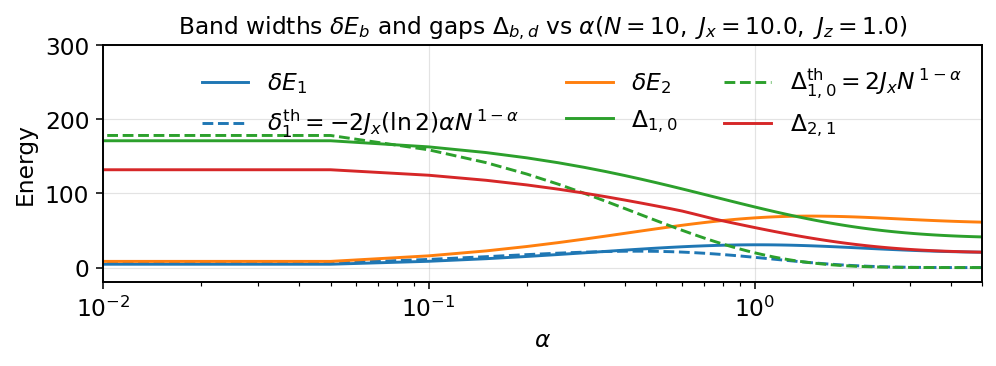

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# Band kets
# -----------------
def band3_ket_x(N: int, i: int, j: int, k: int) -> qt.Qobj:
    if len({i, j, k}) != 3:
        raise ValueError("i, j, k must all be different.")
    if not (0 <= i < N and 0 <= j < N and 0 <= k < N):
        raise ValueError("i, j, k must be valid site indices.")
    plus_x, minus_x = plus_minus_x()
    kets = [minus_x for _ in range(N)]
    kets[i] = plus_x
    kets[j] = plus_x
    kets[k] = plus_x
    return qt.tensor(kets).unit()


def band4_ket_x(N: int, i: int, j: int, k: int, l: int) -> qt.Qobj:
    if len({i, j, k, l}) != 4:
        raise ValueError("i, j, k, l must all be different.")
    if not (0 <= i < N and 0 <= j < N and 0 <= k < N and 0 <= l < N):
        raise ValueError("i, j, k, l must be valid site indices.")
    plus_x, minus_x = plus_minus_x()
    kets = [minus_x for _ in range(N)]
    kets[i] = plus_x
    kets[j] = plus_x
    kets[k] = plus_x
    kets[l] = plus_x
    return qt.tensor(kets).unit()


# -----------------
# Expectation energies by band
# -----------------
def band_expectation_energies(N, Jz, Jx, alpha, kac=True):
    H = build_H(N, Jz, Jx, alpha, kac=kac)

    # --- band 0 ---
    psi0 = band0_ket_x(N)
    E0 = float(qt.expect(H, psi0).real)

    # --- band 1 (N) ---
    j_sites = np.arange(1, N + 1, dtype=int)  # 1..N for plotting labels
    E1 = np.zeros(N, dtype=float)
    for j in range(N):
        E1[j] = float(qt.expect(H, band1_ket_x(N, j)).real)

    # --- band 2 (NC2) ---
    pairs = []
    E2 = []
    for i in range(N):
        for j in range(i + 1, N):
            pairs.append((i + 1, j + 1))  # 1-indexed labels
            E2.append(float(qt.expect(H, band2_ket_x(N, i, j)).real))
    E2 = np.array(E2, dtype=float)

    # --- band 3 (NC3) ---
    triples = []
    E3 = []
    for i in range(N):
        for j in range(i + 1, N):
            for k in range(j + 1, N):
                triples.append((i + 1, j + 1, k + 1))  # 1-indexed labels
                E3.append(float(qt.expect(H, band3_ket_x(N, i, j, k)).real))
    E3 = np.array(E3, dtype=float)

    # --- band 4 (NC4) ---
    quads = []
    E4 = []
    for i in range(N):
        for j in range(i + 1, N):
            for k in range(j + 1, N):
                for l in range(k + 1, N):
                    quads.append((i + 1, j + 1, k + 1, l + 1))  # 1-indexed labels
                    E4.append(float(qt.expect(H, band4_ket_x(N, i, j, k, l)).real))
    E4 = np.array(E4, dtype=float)

    return H, E0, (j_sites, E1), (pairs, E2), (triples, E3), (quads, E4)


def compute_band_metrics(N, Jz, Jx, alphas, kac=True):
    """
    Returns arrays:
      gaps:
        gap_b1_b0[α] = mean(E1) - E0
        gap_b2_b1[α] = mean(E2) - mean(E1)
        gap_b3_b2[α] = mean(E3) - mean(E2)
        gap_b4_b3[α] = mean(E4) - mean(E3)
        gap_b3_b1[α] = mean(E3) - mean(E1)
        gap_b4_b2[α] = mean(E4) - mean(E2)

      bandwidths:
        bw_b1[α] = max(E1) - min(E1)
        bw_b2[α] = max(E2) - min(E2)
        bw_b3[α] = max(E3) - min(E3)
        bw_b4[α] = max(E4) - min(E4)
    """
    gap_b1_b0 = np.empty_like(alphas, dtype=float)
    gap_b2_b1 = np.empty_like(alphas, dtype=float)
    gap_b3_b2 = np.empty_like(alphas, dtype=float)
    gap_b4_b3 = np.empty_like(alphas, dtype=float)
    gap_b3_b1 = np.empty_like(alphas, dtype=float)
    gap_b4_b2 = np.empty_like(alphas, dtype=float)

    bw_b1 = np.empty_like(alphas, dtype=float)
    bw_b2 = np.empty_like(alphas, dtype=float)
    bw_b3 = np.empty_like(alphas, dtype=float)
    bw_b4 = np.empty_like(alphas, dtype=float)

    for kk, alpha in enumerate(alphas):
        H, E0, (j_sites, E1), (pairs, E2), (triples, E3), (quads, E4) = band_expectation_energies(
            N, Jz, Jx, float(alpha), kac=kac
        )

        m1 = float(np.median(E1))
        m2 = float(np.median(E2))
        m3 = float(np.median(E3))
        m4 = float(np.median(E4))

        gap_b1_b0[kk] = m1 - float(E0)
        gap_b2_b1[kk] = m2 - m1
        gap_b3_b2[kk] = m3 - m2
        gap_b4_b3[kk] = m4 - m3
        gap_b3_b1[kk] = m3 - m1
        gap_b4_b2[kk] = m4 - m2

        bw_b1[kk] = float(np.max(E1) - np.min(E1))
        bw_b2[kk] = float(np.max(E2) - np.min(E2))
        bw_b3[kk] = float(np.max(E3) - np.min(E3))
        bw_b4[kk] = float(np.max(E4) - np.min(E4))

    return (
        gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
        bw_b1, bw_b2, bw_b3, bw_b4
    )


def plot_band_metrics(
    alphas,
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4,
    savepath="band_metrics.png",
    N=None, Jx=None, Jz=None, kac=None,
):
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.linewidth": 1,
        "lines.linewidth": 1.5,
    })

    fig, ax = plt.subplots(figsize=(7, 2.5), constrained_layout=True)
    deltaE1_th = 2.0 * -Jx * np.log(2.0) * alphas * (N ** (1.0 - alphas))
    # DeltaE1_th = 2.0 * -Jx * ((N-3) ** (1.0 - alphas))

    Halpha = np.array([np.sum(1.0 / (np.arange(1, N) ** a)) if a != 0 else (N-1) for a in alphas])
    # DeltaE1_th = 2.0 * -Jx * Halpha
    DeltaE1_th = 2.0 * -Jx * (N**(1-alphas))/(1)
    # --- plot all series (as you had) ---
    (line_bw1,) = ax.semilogx(alphas, bw_b1, label=r"$\delta E_{1}$")
    
    ax.semilogx(
        alphas,
        deltaE1_th,
        linestyle="--",
        linewidth=1.5,
        color=line_bw1.get_color(),
        label=r"$\delta_{1}^{\mathrm{th}}=-2 J_x(\ln 2)\alpha N^{\,1-\alpha}$",
    )
    ax.semilogx(alphas, bw_b2, label=r"$\delta E_{2}$")
    # ax.plot(alphas, bw_b3, label=r"$\delta E_{3}$")
    # ax.plot(alphas, bw_b4, label=r"$\delta E_{4}$")

    (line_gap1,) = ax.semilogx(alphas, gap_b1_b0, label=r"$\Delta_{1,0}$")
    ax.semilogx(
        alphas,
        DeltaE1_th,
        linestyle="--",
        linewidth=1.5,
        color=line_gap1.get_color(),
        label=r"$\Delta_{1,0}^{\mathrm{th}}=2J_x N^{\,1-\alpha}$",
    )

    ax.semilogx(alphas, gap_b2_b1, label=r"$\Delta_{2,1}$")
    # ax.plot(alphas, gap_b3_b2, label=r"$\Delta_{3,2}$")
    # ax.plot(alphas, gap_b4_b3, label=r"$\Delta_{4,3}$")
    # ax.plot(alphas, gap_b3_b1, label=r"$\Delta_{3,1}$")
    # ax.plot(alphas, gap_b4_b2, label=r"$\Delta_{4,2}$")


    # DeltaE1_th = 4.0 * Jx * (N-1)/((N) ** (1-alphas))
    #analytics
    # --- numerical ---
    # (line_bw1,) = ax.plot(alphas, bw_b1, label=r"$\delta E_{1}$")
    # (line_gap1,) = ax.plot(alphas, gap_b1_b0, label=r"$\Delta_{1,0}$")

    # --- analytic (same color, dashed) ---




    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Energy")

    ax.set_xlim(1e-2, 5)
    ax.set_ylim(-20, 300)
    title1 = r"Band widths $\delta E_b$ and gaps $\Delta_{b,d}$ vs $\alpha$"
    if (N is not None) and (Jx is not None) and (Jz is not None) and (kac is not None):
        title2 = rf"$ (N={N},\ J_x={-Jx},\ J_z={-Jz})$"
        ax.set_title( title1 + title2, fontsize=12)
    else:
        ax.set_title(fontsize=12)

    ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
    ax.legend(loc="best", frameon=False, ncol=3, fontsize=12)

    fig.savefig(savepath, bbox_inches="tight")
    return fig, ax
# -----------------
# Usage
# -----------------
alphas = np.linspace(0.0, 5.0, 101)

(
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4
) = compute_band_metrics(N, Jz, Jx, alphas, kac=False)

fig, ax = plot_band_metrics(
    alphas,
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4,
    savepath="plt/band_metrics.pdf",
    N=N, Jx=Jx, Jz=Jz, kac=False,
)
plt.show()

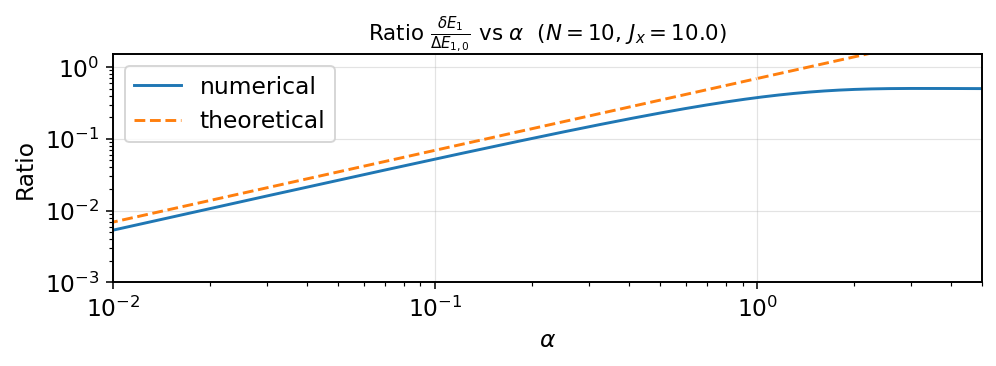

In [18]:
# ------------------------------------------------------------
# Plot ratio: (band-1 bandwidth) / (band gap 0->1)
# plus a "theory ratio" using the same theoretical lines you defined.
# (kept separate from your other plotting function)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def plot_bw1_over_gap01_ratio(alphas, bw_b1, gap_b1_b0, *, N, Jx, savepath="plt/ratio_bw1_gap01.pdf"):
    alphas = np.asarray(alphas, dtype=float)
    bw_b1 = np.asarray(bw_b1, dtype=float)
    gap_b1_b0 = np.asarray(gap_b1_b0, dtype=float)

    # ----------------------------
    # Numerical ratio (use absolute gap to avoid sign-convention issues)
    # ----------------------------
    eps = 1e-14
    ratio_num = bw_b1 / (np.abs(gap_b1_b0) + eps)

    # ----------------------------
    # "Theory lines" (as in your snippet)
    # NOTE: these are not generally correct for all geometries,
    # but I'm using your same definitions because you asked.
    # ----------------------------
    deltaE1_th = 2.0 * (-Jx) * np.log(2.0) * alphas * (N ** (1.0 - alphas))

    # Your asymptotic gap formula diverges at alpha=1; handle safely:
    DeltaE1_th = np.full_like(alphas, np.nan, dtype=float)
    mask = np.abs(1.0 - alphas) > 1e-10
    DeltaE1_th[mask] = 2.0 * (-Jx) * (N ** (1.0 - alphas[mask]))

    ratio_th = np.abs(deltaE1_th) / (np.abs(DeltaE1_th) + eps)

    # ----------------------------
    # Plot
    # ----------------------------
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 11,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.linewidth": 1,
        "lines.linewidth": 1.5,
    })

    fig, ax = plt.subplots(figsize=(7, 2.5), constrained_layout=True)

    # alpha=0 makes semilogx unhappy; start from a small positive floor for plotting
    alpha_plot = np.clip(alphas, 1e-3, None)

    ax.loglog(alpha_plot, ratio_num, label=r"numerical")
    ax.loglog(alpha_plot, ratio_th, "--", label=r"theoretical")

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"Ratio")

    ax.set_ylim(1e-3,1.5)
    ax.set_xlim(1e-2,5)
    ax.set_title(rf"Ratio $\frac{{\delta E_1}}{{\Delta E_{{1,0}}}}$ vs $\alpha$  ($N={N},\,J_x={-Jx}$)")
    ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
    ax.legend(loc="best", frameon=True)

    fig.savefig(savepath, bbox_inches="tight")
    return fig, ax


# -----------------
# Usage (after you computed arrays)
# -----------------
alphas = np.linspace(0.0, 5.0, 1001)

(
    gap_b1_b0, gap_b2_b1, gap_b3_b2, gap_b4_b3, gap_b3_b1, gap_b4_b2,
    bw_b1, bw_b2, bw_b3, bw_b4
) = compute_band_metrics(N, Jz, Jx, alphas, kac=False)

fig, ax = plot_bw1_over_gap01_ratio(
    alphas, bw_b1, gap_b1_b0,
    N=N, Jx=Jx,
    savepath="plt/ratio_bw1_gap01.pdf",
)
plt.show()


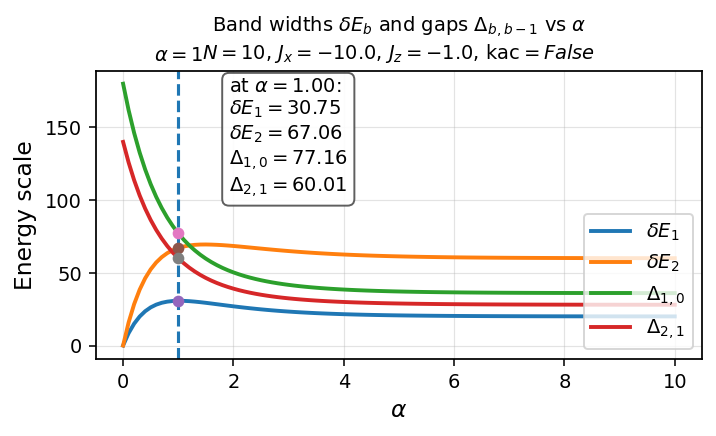

(<Figure size 700x420 with 1 Axes>,
 <Axes: title={'center': 'Ratios $\\delta E_b / \\Delta_{b,b-1}$ vs $\\alpha$\n$N=10$, $J_x=-10.0$, $J_z=-1.0$, $\\mathrm{kac}=False$'}, xlabel='$\\alpha$', ylabel='Bandwidth / gap'>)

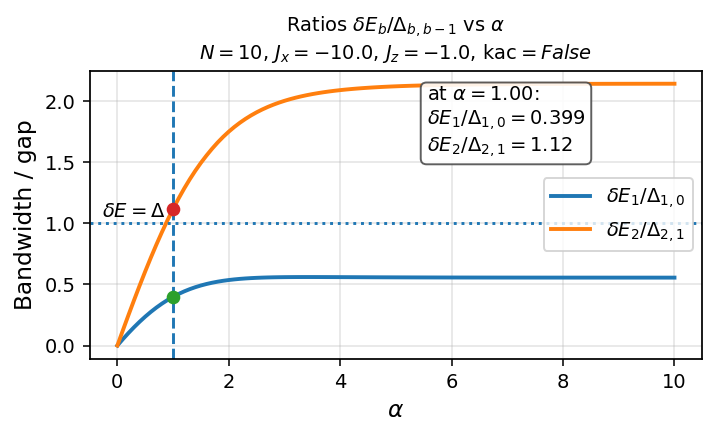

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def plot_band_metrics(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=1.0, savepath="band_metrics.png",
    N=None, Jx=None, Jz=None, kac=None,
):
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.linewidth": 0.9,
        "lines.linewidth": 2.0,
    })

    alphas = np.asarray(alphas, dtype=float)

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    # Curves
    ax.plot(alphas, bw_b1,     label=r"$\delta E_{1}$")
    ax.plot(alphas, bw_b2,     label=r"$\delta E_{2}$")
    ax.plot(alphas, gap_b1_b0, label=r"$\Delta_{1,0}$")
    ax.plot(alphas, gap_b2_b1, label=r"$\Delta_{2,1}$")

    # Vertical marker
    ax.axvline(alpha_marker, linestyle="--", linewidth=1.6)
    ax.text(alpha_marker, 1.02, rf"$\alpha={alpha_marker:g}$",
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom")

    # Nearest grid point to alpha_marker
    idx = int(np.argmin(np.abs(alphas - alpha_marker)))
    x0 = float(alphas[idx])

    series = [bw_b1, bw_b2, gap_b1_b0, gap_b2_b1]

    # Mark points + annotation
    yvals = []
    for arr in series:
        y = float(np.asarray(arr, dtype=float)[idx])
        yvals.append(y)
        ax.plot([x0], [y], marker="o", markersize=5)

    annotation_lines = [
        rf"at $\alpha={x0:.2f}$:",
        rf"$\delta E_1 = {yvals[0]:.4g}$",
        rf"$\delta E_2 = {yvals[1]:.4g}$",
        rf"$\Delta_{{1,0}} = {yvals[2]:.4g}$",
        rf"$\Delta_{{2,1}} = {yvals[3]:.4g}$",
    ]

    ax.annotate(
        "\n".join(annotation_lines),
        xy=(x0, max(yvals)),
        xytext=(0.22, 0.98),
        textcoords="axes fraction",
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.3", alpha=0.9),
    )

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Energy scale")

    # Title (safe: build in pieces)
    title = r"Band widths $\delta E_b$ and gaps $\Delta_{b,b-1}$ vs $\alpha$"
    meta = []
    if N is not None:  meta.append(rf"$N={N}$")
    if Jx is not None: meta.append(rf"$J_x={Jx}$")
    if Jz is not None: meta.append(rf"$J_z={Jz}$")
    if kac is not None: meta.append(rf"$\mathrm{{kac}}={kac}$")
    if meta:
        title += "\n" + ", ".join(meta)

    ax.set_title(title, fontsize=10)
    ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
    ax.legend(loc="lower right", frameon=True)

    fig.savefig(savepath, bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_band_overlap_ratios(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=1.0, savepath="band_overlap_ratios.png",
    N=None, Jx=None, Jz=None, kac=None,
):
    """
    Plots:
        δE1 / Δ_{1,0}   and   δE2 / Δ_{2,1}
    """

    # Safe ratios (avoid divide-by-zero)
    ratio_10 = np.where(gap_b1_b0 != 0, bw_b1 / gap_b1_b0, np.nan)
    ratio_21 = np.where(gap_b2_b1 != 0, bw_b2 / gap_b2_b1, np.nan)

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    ax.plot(alphas, ratio_10, label=r"$\delta E_1 / \Delta_{1,0}$")
    ax.plot(alphas, ratio_21, label=r"$\delta E_2 / \Delta_{2,1}$")

    # Reference line: overlap threshold
    ax.axhline(1.0, linestyle=":", linewidth=1.5)
    ax.text(0.02, 1.02, r"$\delta E = \Delta$",
            transform=ax.get_yaxis_transform(),
            ha="left", va="bottom")

    # Vertical marker
    ax.axvline(alpha_marker, linestyle="--", linewidth=1.5)

    # Mark values at alpha_marker
    idx = int(np.argmin(np.abs(alphas - alpha_marker)))
    x0 = float(alphas[idx])

    y1 = ratio_10[idx]
    y2 = ratio_21[idx]

    ax.plot([x0], [y1], "o")
    ax.plot([x0], [y2], "o")

    ax.annotate(
        "\n".join([
            rf"at $\alpha={x0:.2f}$:",
            rf"$\delta E_1/\Delta_{{1,0}}={y1:.3g}$",
            rf"$\delta E_2/\Delta_{{2,1}}={y2:.3g}$",
        ]),
        xy=(x0, max(y1, y2)),
        xytext=(0.55, 0.95),
        textcoords="axes fraction",
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.3", alpha=0.9),
    )

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"Bandwidth / gap")

    title = r"Ratios $\delta E_b / \Delta_{b,b-1}$ vs $\alpha$"
    meta = []
    if N is not None:  meta.append(fr"$N={N}$")
    if Jx is not None: meta.append(fr"$J_x={Jx}$")
    if Jz is not None: meta.append(fr"$J_z={Jz}$")
    if kac is not None: meta.append(fr"$\mathrm{{kac}}={kac}$")
    if meta:
        title += "\n" + ", ".join(meta)

    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.35)
    ax.legend(frameon=True)

    fig.savefig(savepath, bbox_inches="tight")
    return fig, ax

N = 10
Jz = -1.0
Jx = -10.0

plot_band_metrics(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=1.0, N=N, Jx=Jx, Jz=Jz, kac=False
)

plot_band_overlap_ratios(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=1.0, N=N, Jx=Jx, Jz=Jz, kac=False
)


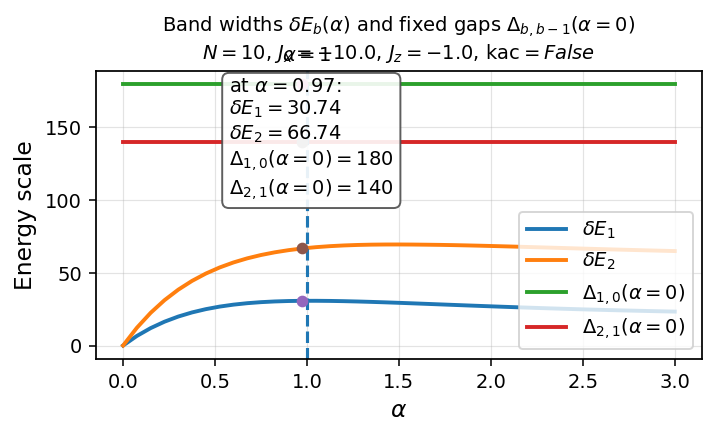

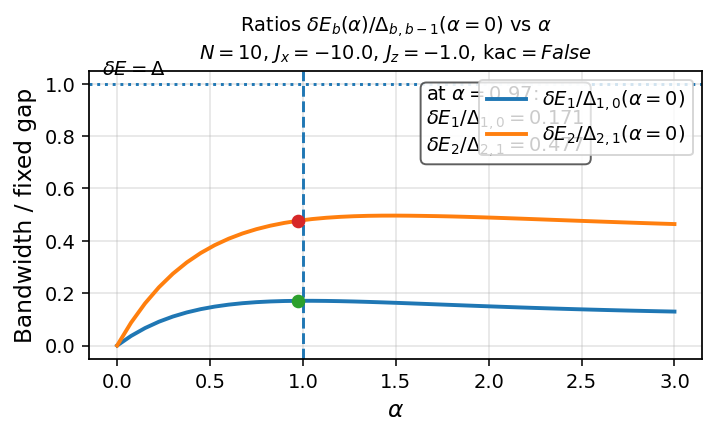

(<Figure size 700x420 with 1 Axes>,
 <Axes: title={'center': 'Ratios $\\delta E_b(\\alpha) / \\Delta_{b,b-1}(\\alpha=0)$ vs $\\alpha$\n$N=10$, $J_x=-10.0$, $J_z=-1.0$, $\\mathrm{kac}=False$'}, xlabel='$\\alpha$', ylabel='Bandwidth / fixed gap'>)

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Compute widths vs alpha, but FIX the gaps using alpha=0
# ------------------------------------------------------------
def compute_widths_and_fixed_gaps(
    N, Jz, Jx,
    alpha_min=0.0, alpha_max=3.0, n_alpha=61,
    kac=True, alpha_ref=0.0,
):
    """
    Returns:
      alphas                 : (n_alpha,)
      bw_b1(alpha), bw_b2(alpha)
      gap_b1_b0_fixed(alpha) : constant array = Delta_{1,0} evaluated at alpha_ref (default 0)
      gap_b2_b1_fixed(alpha) : constant array = Delta_{2,1} evaluated at alpha_ref (default 0)
      Delta10_0, Delta21_0   : the fixed scalar gaps (at alpha_ref)
    """
    alphas = np.linspace(alpha_min, alpha_max, n_alpha)

    bw_b1 = np.zeros_like(alphas, dtype=float)
    bw_b2 = np.zeros_like(alphas, dtype=float)

    # --- fixed gaps from alpha_ref (default alpha=0) ---
    _, E0_ref, (_, E1_ref), (_, E2_ref) = band_expectation_energies(N, Jz, Jx, alpha_ref, kac=kac)
    E1_ref = np.asarray(E1_ref, dtype=float)
    E2_ref = np.asarray(E2_ref, dtype=float)

    E1m_ref = float(np.mean(E1_ref))
    E2m_ref = float(np.mean(E2_ref))
    E0_ref  = float(E0_ref)

    Delta10_0 = E1m_ref - E0_ref
    Delta21_0 = E2m_ref - E1m_ref

    # --- widths change with alpha ---
    for k, a in enumerate(alphas):
        _, _, (_, E1), (_, E2) = band_expectation_energies(N, Jz, Jx, float(a), kac=kac)
        E1 = np.asarray(E1, dtype=float)
        E2 = np.asarray(E2, dtype=float)

        bw_b1[k] = float(np.max(E1) - np.min(E1))
        bw_b2[k] = float(np.max(E2) - np.min(E2))

    gap_b1_b0_fixed = np.full_like(alphas, Delta10_0, dtype=float)
    gap_b2_b1_fixed = np.full_like(alphas, Delta21_0, dtype=float)

    return alphas, bw_b1, bw_b2, gap_b1_b0_fixed, gap_b2_b1_fixed, Delta10_0, Delta21_0


# ------------------------------------------------------------
# 2) Plot widths + (fixed) gaps
# ------------------------------------------------------------
def plot_band_metrics(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=1.0, savepath="band_metrics_fixedgaps.png",
    N=None, Jx=None, Jz=None, kac=None, alpha_ref=0.0,
):
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.linewidth": 0.9,
        "lines.linewidth": 2.0,
    })

    alphas     = np.asarray(alphas, dtype=float)
    gap_b1_b0  = np.asarray(gap_b1_b0, dtype=float)
    gap_b2_b1  = np.asarray(gap_b2_b1, dtype=float)
    bw_b1      = np.asarray(bw_b1, dtype=float)
    bw_b2      = np.asarray(bw_b2, dtype=float)

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    ax.plot(alphas, bw_b1,     label=r"$\delta E_{1}$")
    ax.plot(alphas, bw_b2,     label=r"$\delta E_{2}$")
    ax.plot(alphas, gap_b1_b0, label=rf"$\Delta_{{1,0}}(\alpha={alpha_ref:g})$")
    ax.plot(alphas, gap_b2_b1, label=rf"$\Delta_{{2,1}}(\alpha={alpha_ref:g})$")

    # marker
    ax.axvline(alpha_marker, linestyle="--", linewidth=1.6)
    ax.text(alpha_marker, 1.02, rf"$\alpha={alpha_marker:g}$",
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom")

    # annotate at alpha_marker
    idx = int(np.argmin(np.abs(alphas - alpha_marker)))
    x0 = float(alphas[idx])

    series = [bw_b1, bw_b2, gap_b1_b0, gap_b2_b1]
    yvals = []
    for arr in series:
        y = float(arr[idx])
        yvals.append(y)
        ax.plot([x0], [y], marker="o", markersize=5)

    annotation_lines = [
        rf"at $\alpha={x0:.2f}$:",
        rf"$\delta E_1 = {yvals[0]:.4g}$",
        rf"$\delta E_2 = {yvals[1]:.4g}$",
        rf"$\Delta_{{1,0}}(\alpha={alpha_ref:g}) = {yvals[2]:.4g}$",
        rf"$\Delta_{{2,1}}(\alpha={alpha_ref:g}) = {yvals[3]:.4g}$",
    ]

    ax.annotate(
        "\n".join(annotation_lines),
        xy=(x0, np.max(yvals)),
        xytext=(0.22, 0.98),
        textcoords="axes fraction",
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.3", alpha=0.9),
    )

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Energy scale")

    title = r"Band widths $\delta E_b(\alpha)$ and fixed gaps $\Delta_{b,b-1}(\alpha=0)$"
    meta = []
    if N is not None:  meta.append(rf"$N={N}$")
    if Jx is not None: meta.append(rf"$J_x={Jx}$")
    if Jz is not None: meta.append(rf"$J_z={Jz}$")
    if kac is not None: meta.append(rf"$\mathrm{{kac}}={kac}$")
    if meta:
        title += "\n" + ", ".join(meta)

    ax.set_title(title, fontsize=10)
    ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
    ax.legend(loc="lower right", frameon=True)

    fig.savefig(savepath, bbox_inches="tight")
    plt.show()
    return fig, ax


# ------------------------------------------------------------
# 3) Plot ratios (width / fixed gap)
# ------------------------------------------------------------
def plot_band_overlap_ratios(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=1.0, savepath="band_overlap_ratios_fixedgaps.png",
    N=None, Jx=None, Jz=None, kac=None, alpha_ref=0.0,
):
    alphas     = np.asarray(alphas, dtype=float)
    gap_b1_b0  = np.asarray(gap_b1_b0, dtype=float)
    gap_b2_b1  = np.asarray(gap_b2_b1, dtype=float)
    bw_b1      = np.asarray(bw_b1, dtype=float)
    bw_b2      = np.asarray(bw_b2, dtype=float)

    # ratios using FIXED gaps (note: if you want "distance", use np.abs(gap_*) below)
    ratio_10 = np.where(gap_b1_b0 != 0, bw_b1 / gap_b1_b0, np.nan)
    ratio_21 = np.where(gap_b2_b1 != 0, bw_b2 / gap_b2_b1, np.nan)

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    ax.plot(alphas, ratio_10, label=rf"$\delta E_1 / \Delta_{{1,0}}(\alpha={alpha_ref:g})$")
    ax.plot(alphas, ratio_21, label=rf"$\delta E_2 / \Delta_{{2,1}}(\alpha={alpha_ref:g})$")

    ax.axhline(1.0, linestyle=":", linewidth=1.5)
    ax.text(0.02, 1.02, r"$\delta E = \Delta$",
            transform=ax.get_yaxis_transform(),
            ha="left", va="bottom")

    ax.axvline(alpha_marker, linestyle="--", linewidth=1.5)

    idx = int(np.argmin(np.abs(alphas - alpha_marker)))
    x0 = float(alphas[idx])
    y1 = float(ratio_10[idx])
    y2 = float(ratio_21[idx])

    ax.plot([x0], [y1], "o")
    ax.plot([x0], [y2], "o")

    ax.annotate(
        "\n".join([
            rf"at $\alpha={x0:.2f}$:",
            rf"$\delta E_1/\Delta_{{1,0}}={y1:.3g}$",
            rf"$\delta E_2/\Delta_{{2,1}}={y2:.3g}$",
        ]),
        xy=(x0, np.nanmax([y1, y2])),
        xytext=(0.55, 0.95),
        textcoords="axes fraction",
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.3", alpha=0.9),
    )

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"Bandwidth / fixed gap")

    title = r"Ratios $\delta E_b(\alpha) / \Delta_{b,b-1}(\alpha=0)$ vs $\alpha$"
    meta = []
    if N is not None:  meta.append(rf"$N={N}$")
    if Jx is not None: meta.append(rf"$J_x={Jx}$")
    if Jz is not None: meta.append(rf"$J_z={Jz}$")
    if kac is not None: meta.append(rf"$\mathrm{{kac}}={kac}$")
    if meta:
        title += "\n" + ", ".join(meta)

    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.35)
    ax.legend(frameon=True)

    fig.savefig(savepath, bbox_inches="tight")
    plt.show()
    return fig, ax


# ------------------------------------------------------------
# 4) Example usage (you already have band_expectation_energies)
# ------------------------------------------------------------
N  = 10
Jz = -1.0
Jx = -10.0
kac = False

alpha_min, alpha_max, n_alpha = 0.0, 3.0, 41
alpha_marker = 1.0

alphas, bw_b1, bw_b2, gap_b1_b0, gap_b2_b1, Delta10_0, Delta21_0 = compute_widths_and_fixed_gaps(
    N, Jz, Jx,
    alpha_min=alpha_min, alpha_max=alpha_max, n_alpha=n_alpha,
    kac=kac, alpha_ref=0.0,
)

# Plot widths + fixed gaps
plot_band_metrics(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=alpha_marker,
    N=N, Jx=Jx, Jz=Jz, kac=kac, alpha_ref=0.0,
)

# Plot ratios using fixed gaps
plot_band_overlap_ratios(
    alphas, gap_b1_b0, gap_b2_b1, bw_b1, bw_b2,
    alpha_marker=alpha_marker,
    N=N, Jx=Jx, Jz=Jz, kac=kac, alpha_ref=0.0,
)


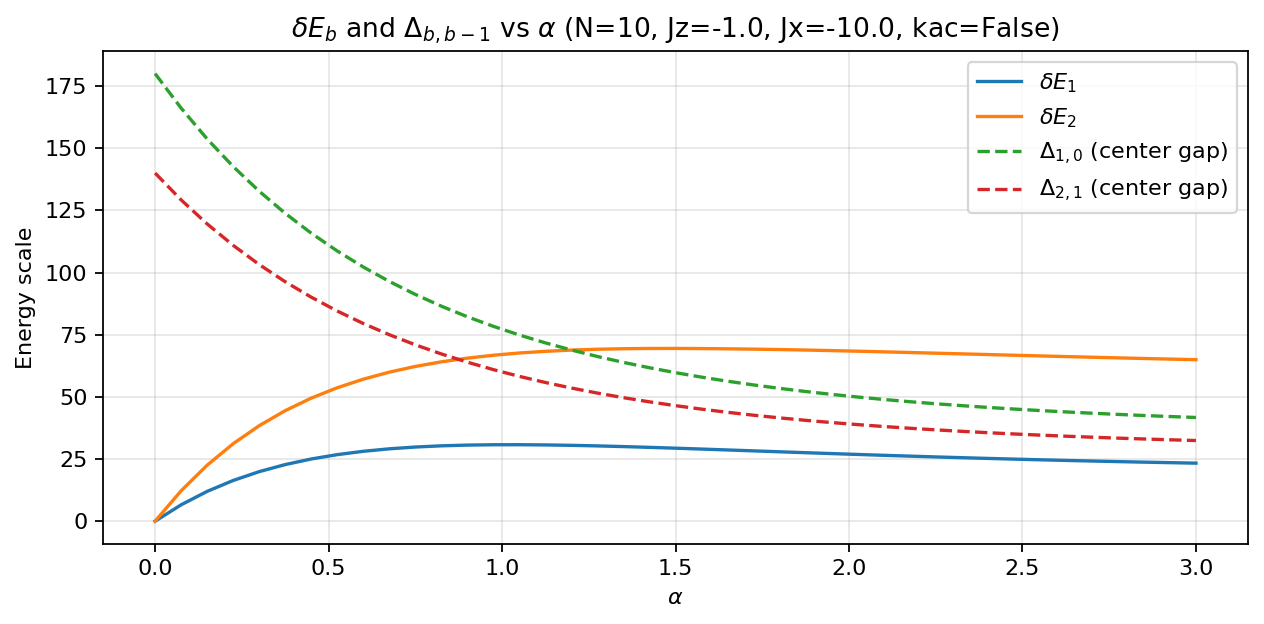

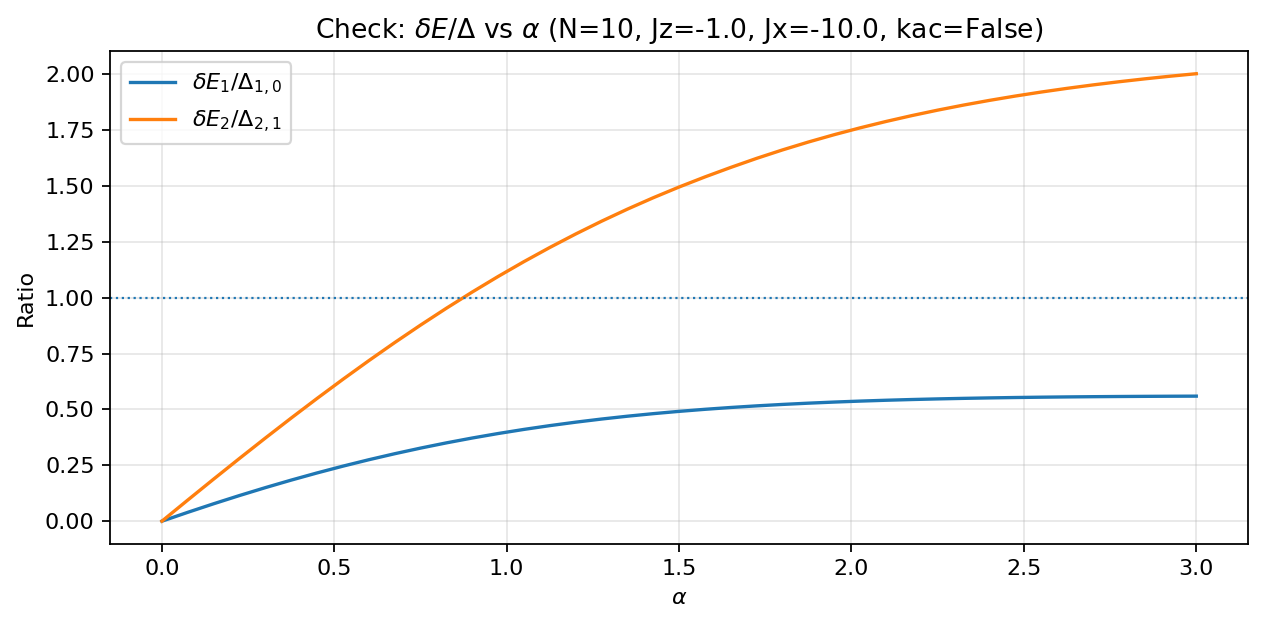

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def band_stats_vs_alpha(
    N, Jz, Jx,
    alpha_min=0.0, alpha_max=3.0, n_alpha=61,
    kac=True,
):
    """
    Computes:
      - deltaE_b(alpha): band width for b=0,1,2
      - Delta_{b,b-1}(alpha): distance between band centers (average energies)
      - ratio deltaE/Delta
    using the energies returned by band_expectation_energies.
    """
    alphas = np.linspace(alpha_min, alpha_max, n_alpha)

    # arrays: shape (n_alpha,)
    E0_mean = np.zeros_like(alphas, dtype=float)
    E1_mean = np.zeros_like(alphas, dtype=float)
    E2_mean = np.zeros_like(alphas, dtype=float)

    dE0 = np.zeros_like(alphas, dtype=float)
    dE1 = np.zeros_like(alphas, dtype=float)
    dE2 = np.zeros_like(alphas, dtype=float)

    D10 = np.zeros_like(alphas, dtype=float)  # Delta_{1,0}
    D21 = np.zeros_like(alphas, dtype=float)  # Delta_{2,1}

    ratio1 = np.zeros_like(alphas, dtype=float)  # dE1 / D10
    ratio2 = np.zeros_like(alphas, dtype=float)  # dE2 / D21

    for k, a in enumerate(alphas):
        _, E0, (_, E1), (_, E2) = band_expectation_energies(N, Jz, Jx, a, kac=kac)

        # band 0
        E0_mean[k] = float(E0)
        dE0[k] = 0.0  # single state

        # band 1
        E1 = np.asarray(E1, dtype=float)
        E1_mean[k] = float(np.mean(E1))
        dE1[k] = float(np.max(E1) - np.min(E1))

        # band 2
        E2 = np.asarray(E2, dtype=float)
        E2_mean[k] = float(np.mean(E2))
        dE2[k] = float(np.max(E2) - np.min(E2))

        # inter-band gaps from centers
        D10[k] = abs(E1_mean[k] - E0_mean[k])
        D21[k] = abs(E2_mean[k] - E1_mean[k])

        # ratios (guard against divide-by-zero)
        ratio1[k] = dE1[k] / D10[k] if D10[k] != 0 else np.nan
        ratio2[k] = dE2[k] / D21[k] if D21[k] != 0 else np.nan

    out = {
        "alphas": alphas,
        "E_mean": {0: E0_mean, 1: E1_mean, 2: E2_mean},
        "deltaE": {0: dE0, 1: dE1, 2: dE2},
        "Delta": {(1,0): D10, (2,1): D21},
        "ratio": {1: ratio1, 2: ratio2},
    }
    return out


def plot_deltaE_and_gaps(stats, title_extra=""):
    alphas = stats["alphas"]
    dE0, dE1, dE2 = stats["deltaE"][0], stats["deltaE"][1], stats["deltaE"][2]
    D10, D21 = stats["Delta"][(1,0)], stats["Delta"][(2,1)]
    r1, r2 = stats["ratio"][1], stats["ratio"][2]

    plt.figure(figsize=(8, 4), dpi=160)
    plt.plot(alphas, dE1, label=r"$\delta E_1$")
    plt.plot(alphas, dE2, label=r"$\delta E_2$")
    plt.plot(alphas, D10, "--", label=r"$\Delta_{1,0}$ (center gap)")
    plt.plot(alphas, D21, "--", label=r"$\Delta_{2,1}$ (center gap)")
    plt.xlabel(r"$\alpha$")
    plt.ylabel("Energy scale")
    plt.title(r"$\delta E_b$ and $\Delta_{b,b-1}$ vs $\alpha$" + (f" {title_extra}" if title_extra else ""))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4), dpi=160)
    plt.plot(alphas, r1, label=r"$\delta E_1/\Delta_{1,0}$")
    plt.plot(alphas, r2, label=r"$\delta E_2/\Delta_{2,1}$")
    plt.axhline(1.0, linestyle=":", linewidth=1)
    plt.xlabel(r"$\alpha$")
    plt.ylabel("Ratio")
    plt.title(r"Check: $\delta E/\Delta$ vs $\alpha$" + (f" {title_extra}" if title_extra else ""))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -----------------------
# Example usage (your params)
# -----------------------
N = 10
Jz = -1.0
Jx = -10.0

stats = band_stats_vs_alpha(N, Jz, Jx, alpha_min=0.0, alpha_max=3.0, n_alpha=41, kac=False)
plot_deltaE_and_gaps(stats, title_extra=rf"(N={N}, Jz={Jz}, Jx={Jx}, kac=False)")



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

def _color_from_E0(E0: float) -> str:
    # Your requested bins (interpreted literally)
    if E0 < -400:
        return "black"
    elif (-300 < E0) and (E0 < -200):
        return "blue"
    elif (-200 <= E0) and (E0 < -100):
        return "red"
    elif (-100 <= E0) and (E0 < 0):
        return "green"
    elif (0 <= E0) and (E0 < 40):
        return "purple"
    else:  # E0 >= 40
        return "cyan"

def plot_spectrum_thresholdcolored(
    N: int,
    Jz: float,
    Jx: float,
    alpha_min: float = 0.0,
    alpha_max: float = 3.0,
    n_alpha: int = 61,
    kac: bool = False,
    max_levels: int | None = None,
    # plotting
    show_lines: bool = True,
    show_points: bool = True,
    line_width: float = 0.7,
    point_size: float = 3.0,
    alpha_points: float = 0.7,
    # marker line
    alpha_marker: float = 1.0,
    marker_ls: str = ":",
    marker_lw: float = 1.5,
):
    """
    Compute sorted spectrum E_n(alpha). Assign a color to each eigenvalue branch
    based on its initial energy E_n(alpha_min), using your threshold bins.
    Then plot each branch with that fixed color (adiabatic-by-order tracking).

    Adds a vertical dotted line at alpha=alpha_marker.
    """

    # ---------- compute spectrum ----------
    alphas = np.linspace(alpha_min, alpha_max, n_alpha)
    dim = 2**N
    E = np.empty((n_alpha, dim), dtype=float)

    for k, a in enumerate(alphas):
        H = build_H(N, Jz, Jx, a, kac=kac)
        E[k, :] = np.sort(np.array(H.eigenenergies(), dtype=float))

    if max_levels is not None:
        E = E[:, :max_levels]

    n_levels = E.shape[1]

    # ---------- colors from alpha=alpha_min ----------
    E0 = E[0, :]
    colors = [_color_from_E0(float(e0)) for e0 in E0]

    # ---------- main plot ----------
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    for n in range(n_levels):
        c = colors[n]
        if show_lines:
            ax.plot(alphas, E[:, n], color=c, lw=line_width)
        if show_points:
            ax.scatter(alphas, E[:, n], color=c, s=point_size, alpha=alpha_points)

    # vertical dotted line at alpha=1 (or chosen marker)
    ax.axvline(alpha_marker, linestyle=marker_ls, linewidth=marker_lw)

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Eigenvalues of $H$")
    ax.set_title(
        "Spectrum vs α\n"
        f"N={N}, Jz={Jz}, Jx={Jx}, kac={kac}"
    )
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    # quick count per bin (handy sanity check)
    from collections import Counter
    counts = Counter(colors)
    print("Counts by color bin (based on E at α=0):", dict(counts))

    return alphas, E, colors

# -----------------------
# Example run
# -----------------------
N = 10
Jz = -1.0
Jx = -10.0
kac = False

plot_spectrum_thresholdcolored(
    N, Jz, Jx,
    alpha_min=0.0, alpha_max=3.0, n_alpha=61,
    kac=kac,
    max_levels=None,     # set e.g. 300 if you want fewer curves
    alpha_marker=1.0,    # dotted vertical line at alpha=1
)


NameError: name 'build_H' is not defined

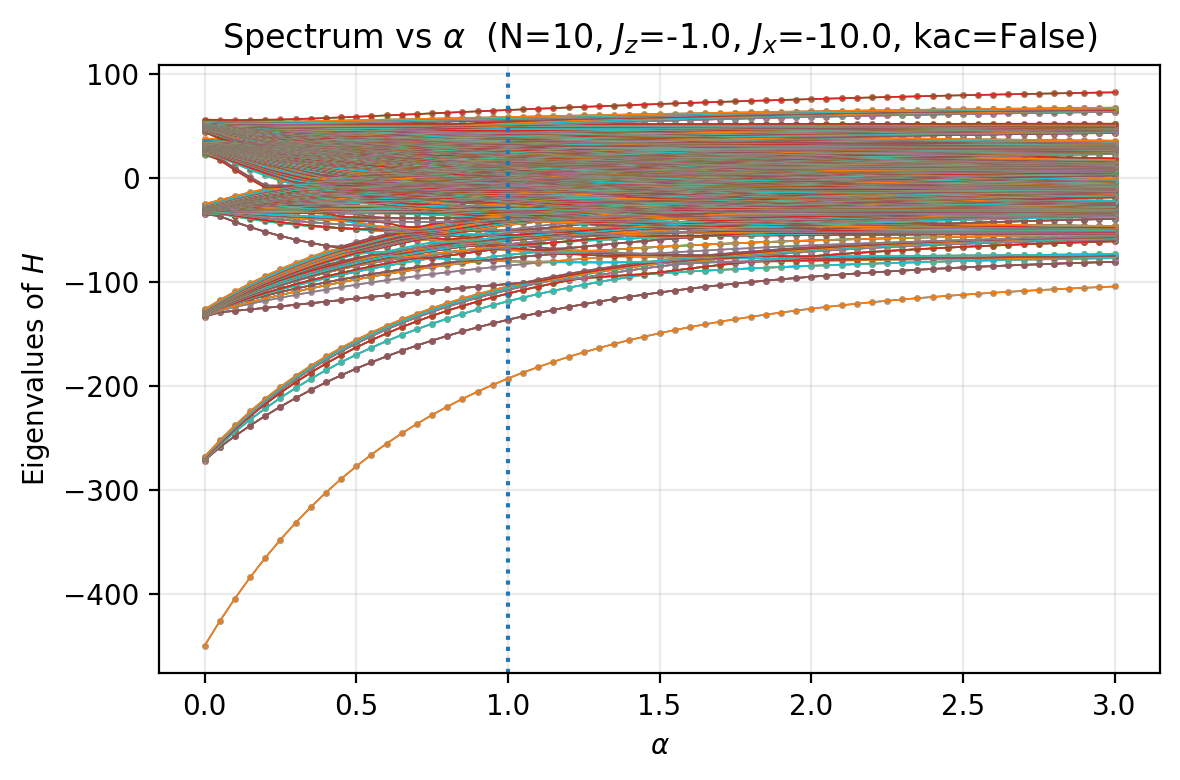

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
        1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
        1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
        2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
        2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  ]),
 array([[-450.02812579, -450.02812578, -271.95539478, ...,   54.98311492,
           55.50906931,   56.11464997],
        [-426.45485497, -426.45485496, -259.16526442, ...,   54.24127013,
           54.8488464 ,   55.78955139],
        [-404.59732197, -404.59732195, -248.35026177, ...,   54.03174121,
           54.7819289 ,   55.72233099],
        ...,
        [-105.75074095, -105.7506935 ,  -81.61142063, ...,   67.26089654,
           81.76794433,   81.76844311],
        [-105.08958305, -105.08953295,  -81.157757  , ...,   67.40112243,
           82.02362367,   82.02410729],
 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

def plot_spectrum_simple(
    N: int,
    Jz: float,
    Jx: float,
    alpha_min: float = 0.0,
    alpha_max: float = 3.0,
    n_alpha: int = 61,
    kac: bool = False,
    max_levels: int | None = None,
    # plotting
    show_lines: bool = True,
    show_points: bool = True,
    line_width: float = 0.6,
    point_size: float = 2.0,
    alpha_points: float = 0.6,
    # marker line
    alpha_marker: float = 1.0,
    marker_ls: str = ":",
    marker_lw: float = 1.5,
):
    """
    Compute sorted spectrum E_n(alpha) and plot it as bands.
    Adds a vertical dotted line at alpha=alpha_marker.
    """

    alphas = np.linspace(alpha_min, alpha_max, n_alpha)
    dim = 2**N
    E = np.empty((n_alpha, dim), dtype=float)

    for k, a in enumerate(alphas):
        H = build_H(N, Jz, Jx, a, kac=kac)
        E[k, :] = np.sort(np.array(H.eigenenergies(), dtype=float))

    if max_levels is not None:
        E = E[:, :max_levels]

    n_levels = E.shape[1]

    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    # single color for everything
    for n in range(n_levels):
        if show_lines:
            ax.plot(alphas, E[:, n], lw=line_width)
        if show_points:
            ax.scatter(alphas, E[:, n], s=point_size, alpha=alpha_points)

    ax.axvline(alpha_marker, linestyle=marker_ls, linewidth=marker_lw)

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Eigenvalues of $H$")
    ax.set_title(rf"Spectrum vs $\alpha$  (N={N}, $J_z$={Jz}, $J_x$={Jx}, kac={kac})")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    return alphas, E

# -----------------------
# Example
# -----------------------
N = 10
Jz = -1.0
Jx = -10.0
kac = False

plot_spectrum_simple(
    N, Jz, Jx,
    alpha_min=0.0, alpha_max=3.0, n_alpha=61,
    kac=kac,
    max_levels=None,     # set e.g. 300 for fewer curves
    alpha_marker=1.0
)


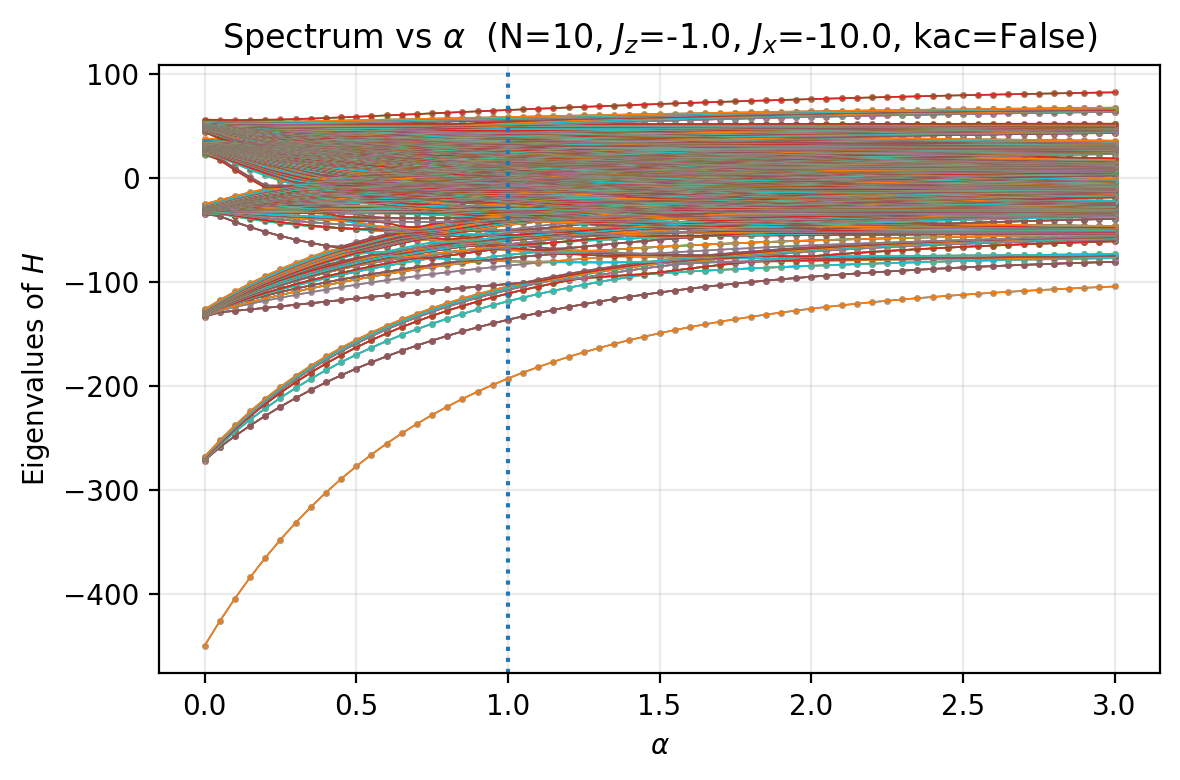

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
        1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
        1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
        2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
        2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  ]),
 array([[-450.02812579, -450.02812578, -271.95539478, ...,   54.98311492,
           55.50906931,   56.11464997],
        [-426.45485497, -426.45485496, -259.16526442, ...,   54.24127013,
           54.8488464 ,   55.78955139],
        [-404.59732197, -404.59732195, -248.35026177, ...,   54.03174121,
           54.7819289 ,   55.72233099],
        ...,
        [-105.75074095, -105.7506935 ,  -81.61142063, ...,   67.26089654,
           81.76794433,   81.76844311],
        [-105.08958305, -105.08953295,  -81.157757  , ...,   67.40112243,
           82.02362367,   82.02410729],
 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

def plot_spectrum_simple(
    N: int,
    Jz: float,
    Jx: float,
    alpha_min: float = 0.0,
    alpha_max: float = 3.0,
    n_alpha: int = 61,
    kac: bool = False,
    max_levels: int | None = None,
    # plotting
    show_lines: bool = True,
    show_points: bool = True,
    line_width: float = 0.6,
    point_size: float = 2.0,
    alpha_points: float = 0.6,
    # marker line
    alpha_marker: float = 1.0,
    marker_ls: str = ":",
    marker_lw: float = 1.5,
    # ---- NEW: drop even-x-excitation bands 2,4,6,... ----
    drop_even_xbands: bool = True,
    tol_Nx: float = 0.35,      # closeness to nearest integer in <Nx>
    drop_even_ge: int = 2,     # drop even bands >= this (keeps band 0)
):
    """
    Compute sorted spectrum E_n(alpha) and plot it as bands.
    Adds a vertical dotted line at alpha=alpha_marker.

    If drop_even_xbands=True:
      - Define excitation as spin-up in x basis (|+>), count operator Nx
      - Drop eigenstates with <Nx> close to even integers 2,4,6,...
      - Keep band 0 (Nx~0) and odd bands (1,3,5,...) by default
    """

    alphas = np.linspace(alpha_min, alpha_max, n_alpha)
    dim = 2**N
    E = np.full((n_alpha, dim), np.nan, dtype=float)  # NaN-pad for dropped states

    # --- NEW: Nx operator (x-basis excitations: |+> counts as 1) ---
    if drop_even_xbands:
        I2 = qt.qeye(2)
        sx = qt.sigmax()
        Nx = 0
        for i in range(N):
            op_list = [I2] * N
            op_list[i] = (I2 + sx) / 2
            Nx += qt.tensor(op_list)

    for k, a in enumerate(alphas):
        H = build_H(N, Jz, Jx, a, kac=kac)

        if not drop_even_xbands:
            Ek = np.sort(np.array(H.eigenenergies(), dtype=float))
        else:
            evals, evecs = H.eigenstates()
            keep = []
            for En, psi in zip(evals, evecs):
                nbar = float(qt.expect(Nx, psi))
                nround = int(np.rint(nbar))
                close = abs(nbar - nround) < tol_Nx
                is_even = (nround % 2 == 0)

                drop = (close and is_even and nround >= drop_even_ge)

                # keep band-0 even though even
                if close and nround == 0:
                    drop = False

                if not drop:
                    keep.append(float(En))

            Ek = np.sort(np.array(keep, dtype=float))

        if max_levels is not None:
            Ek = Ek[:max_levels]

        E[k, :len(Ek)] = Ek  # rest stay NaN

    # determine how many curves to plot (common non-NaN columns)
    # (optional: you can just use max_levels if you set it)
    if max_levels is None:
        # plot only columns that have at least one non-NaN entry
        n_levels = int(np.max(np.sum(~np.isnan(E), axis=1)))
    else:
        n_levels = E.shape[1]

    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    for n in range(n_levels):
        y = E[:, n]
        if show_lines:
            ax.plot(alphas, y, lw=line_width)
        if show_points:
            ax.scatter(alphas, y, s=point_size, alpha=alpha_points)

    ax.axvline(alpha_marker, linestyle=marker_ls, linewidth=marker_lw)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Eigenvalues of $H$")
    ax.set_title(rf"Spectrum vs $\alpha$  (N={N}, $J_z$={Jz}, $J_x$={Jx}, kac={kac})")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return alphas, E


# -----------------------
# Example
# -----------------------
N = 10
Jz = -1.0
Jx = -10.0
kac = False

plot_spectrum_simple(
    N, Jz, Jx,
    alpha_min=0.0, alpha_max=3.0, n_alpha=61,
    kac=kac,
    max_levels=None,
    alpha_marker=1.0,
    drop_even_xbands=True,
    tol_Nx=0.35,
    drop_even_ge=2,
)
